In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [2]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [3]:
# Load data
df = pd.read_csv("merged_companies_housing.csv")

In [4]:
print("="*80)
print("FIRMSCAPE: EXPLORATORY DATA ANALYSIS")
print("Industry Concentration & Housing Market Trends")
print("="*80)

FIRMSCAPE: EXPLORATORY DATA ANALYSIS
Industry Concentration & Housing Market Trends


In [5]:
# ============================================================================
# 1. DATA OVERVIEW
# ============================================================================
print("\n" + "="*80)
print("1. DATA OVERVIEW")
print("="*80)


1. DATA OVERVIEW


In [6]:
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Dataset Shape: 275,438 rows × 15 columns

Columns: ['name', 'industry', 'size', 'type', 'founded', 'city_x', 'state', 'country_code', 'date', 'city_y', 'cbsa_code', 'hpi_index', 'pct_change', 'earliest_housing_date', 'latest_housing_date']

Data Types:
name                      object
industry                  object
size                      object
type                      object
founded                    int64
city_x                    object
state                     object
country_code              object
date                      object
city_y                    object
cbsa_code                float64
hpi_index                float64
pct_change               float64
earliest_housing_date     object
latest_housing_date       object
dtype: object

Missing Values:
name                        18
industry                  1692
size                         0
type                     11902
founded                      0
city_x                    4036
state                     8723
cou

In [7]:
# ============================================================================
# 2. CONVERT FIRM SIZE
# ============================================================================
print("\n" + "="*80)
print("2. FIRM SIZE CONVERSION")
print("="*80)


2. FIRM SIZE CONVERSION


In [8]:
def convert_size(value):
    if isinstance(value, str):
        value = value.replace(',', '').strip()
        
        if '+' in value:
            value = value.replace('+', '')
            if 'K' in value:
                return float(value.replace('K', '')) * 1000
            else:
                return float(value)
        
        if '-' in value:
            low, high = value.split('-')
            
            def parse_number(x):
                x = x.strip()
                if 'K' in x:
                    return float(x.replace('K', '')) * 1000
                else:
                    return float(x)
            
            return (parse_number(low) + parse_number(high)) / 2
    
    return None

In [9]:
df['size_numeric'] = df['size'].apply(convert_size)

In [10]:
print(f"\nOriginal size values (sample):\n{df['size'].value_counts().head(10)}")
print(f"\nConverted size statistics:")
print(df['size_numeric'].describe())


Original size values (sample):
size
51-200     193235
201-500     54697
1K-5K       18739
10K+         5258
5K-10K       3509
Name: count, dtype: int64

Converted size statistics:
count    275438.000000
mean        648.192301
std        1689.133484
min         125.500000
25%         125.500000
50%         125.500000
75%         350.500000
max       10000.000000
Name: size_numeric, dtype: float64


In [11]:
# ============================================================================
# 3. GEOGRAPHIC DISTRIBUTION
# ============================================================================
print("\n" + "="*80)
print("3. GEOGRAPHIC DISTRIBUTION")
print("="*80)


3. GEOGRAPHIC DISTRIBUTION


In [12]:
print(f"\nNumber of unique cities: {df['city_x'].nunique()}")
print(f"\nTop 15 cities by company count:")
city_counts = df['city_x'].value_counts().head(15)
print(city_counts)


Number of unique cities: 13330

Top 15 cities by company count:
city_x
New York         9185
Houston          4806
Los Angeles      3798
Chicago          3764
San Francisco    3430
Dallas           2897
Miami            2757
Atlanta          2680
Austin           2611
Washington       2446
San Diego        2205
Boston           2041
Denver           1735
Seattle          1721
Phoenix          1704
Name: count, dtype: int64


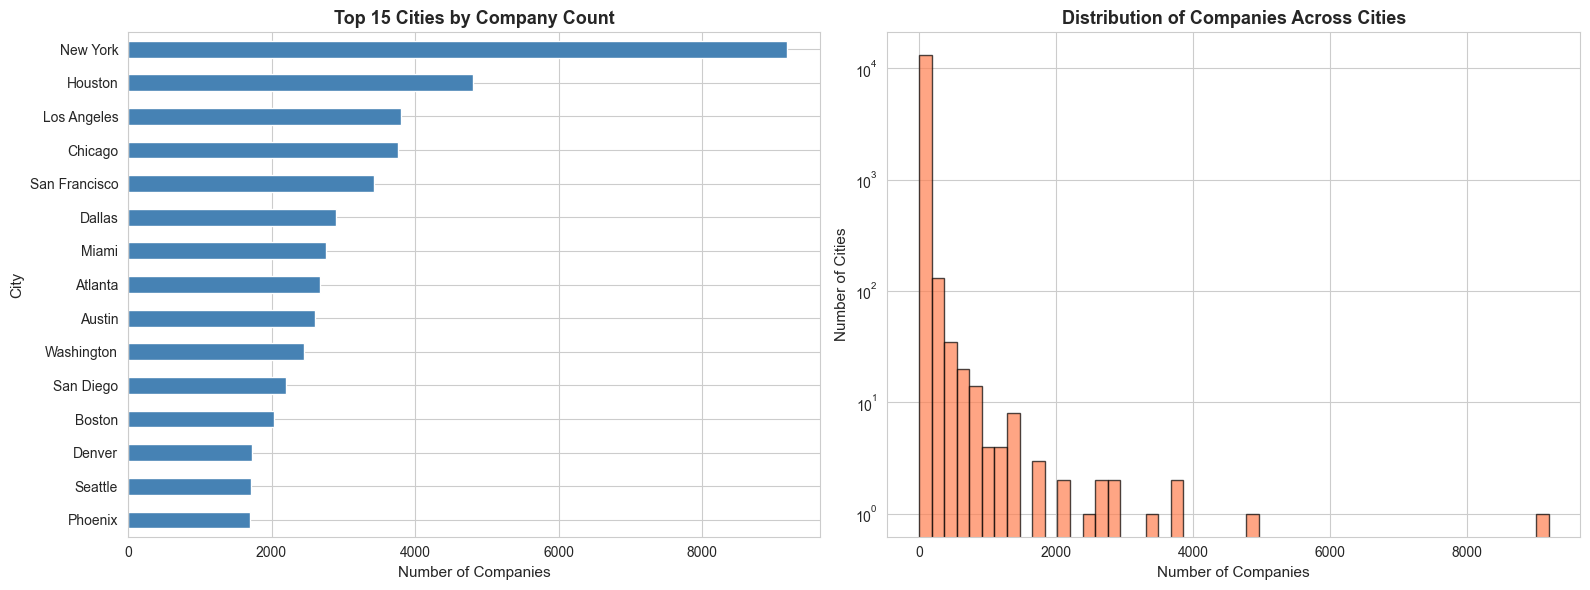

In [13]:
# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top cities by company count
city_counts.head(15).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Number of Companies', fontsize=11)
ax1.set_ylabel('City', fontsize=11)
ax1.set_title('Top 15 Cities by Company Count', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Companies per city distribution
ax2.hist(df['city_x'].value_counts(), bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Number of Companies', fontsize=11)
ax2.set_ylabel('Number of Cities', fontsize=11)
ax2.set_title('Distribution of Companies Across Cities', fontsize=13, fontweight='bold')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


In [14]:
# ============================================================================
# 4. INDUSTRY ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("4. INDUSTRY ANALYSIS")
print("="*80)


4. INDUSTRY ANALYSIS



Number of unique industries: 470

Top 15 industries by company count:
industry
construction                     16316
hospitals and health care        14108
it services and it consulting    11351
software development              8847
real estate                       7324
financial services                7018
non-profit organizations          6530
higher education                  6158
advertising services              5609
hospitality                       5603
staffing and recruiting           4395
retail                            4203
motor vehicle manufacturing       4019
oil and gas                       4009
insurance                         3908
Name: count, dtype: int64


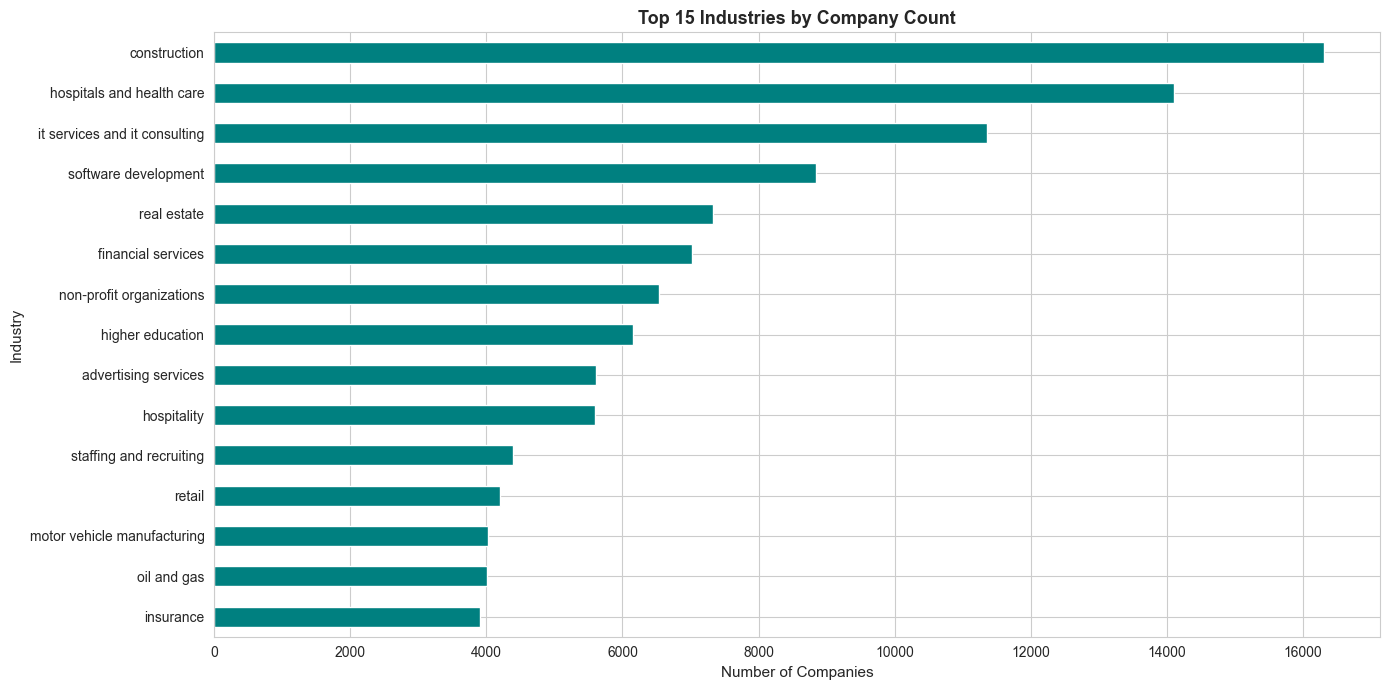

In [15]:
if 'industry' in df.columns:
    print(f"\nNumber of unique industries: {df['industry'].nunique()}")
    print(f"\nTop 15 industries by company count:")
    industry_counts = df['industry'].value_counts().head(15)
    print(industry_counts)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 7))
    industry_counts.plot(kind='barh', ax=ax, color='teal')
    ax.set_xlabel('Number of Companies', fontsize=11)
    ax.set_ylabel('Industry', fontsize=11)
    ax.set_title('Top 15 Industries by Company Count', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [16]:
# ============================================================================
# 5. FIRM SIZE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("5. FIRM SIZE ANALYSIS")
print("="*80)


5. FIRM SIZE ANALYSIS


In [17]:
print(f"\nFirm Size Distribution:")
print(df['size_numeric'].describe())


Firm Size Distribution:
count    275438.000000
mean        648.192301
std        1689.133484
min         125.500000
25%         125.500000
50%         125.500000
75%         350.500000
max       10000.000000
Name: size_numeric, dtype: float64


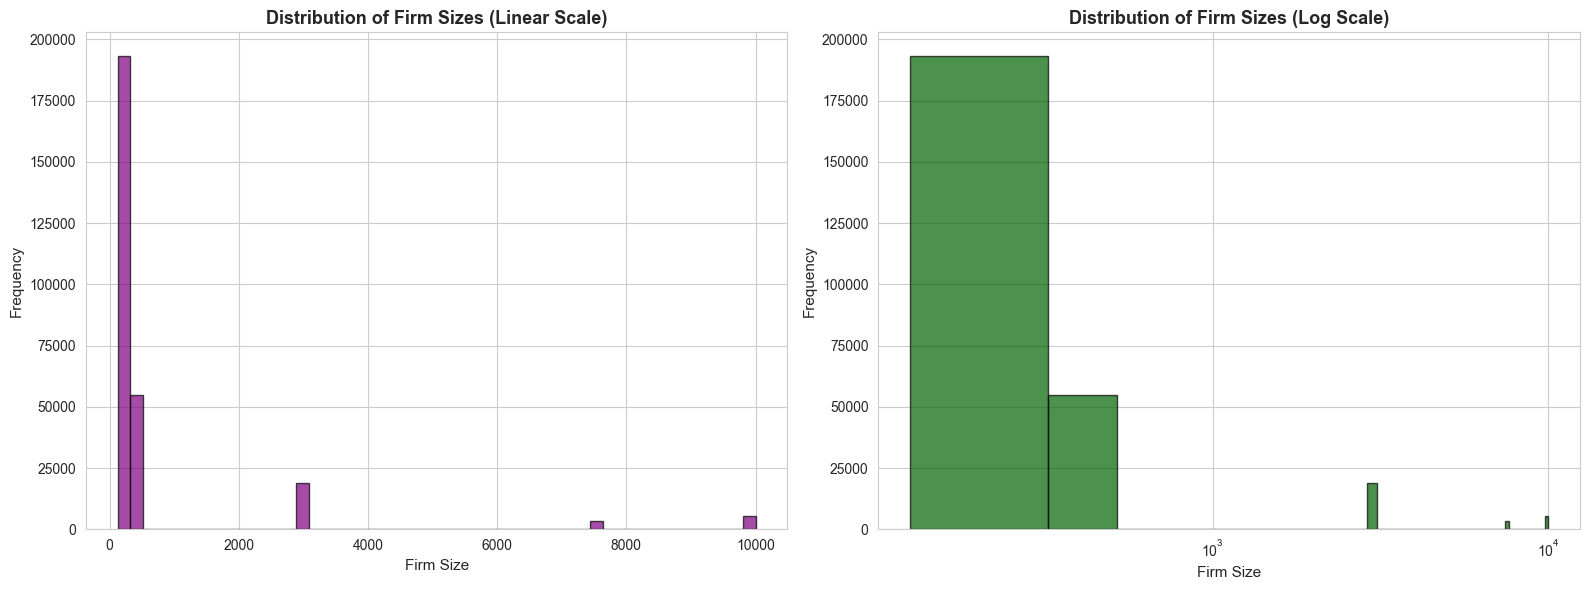

In [18]:
# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1.hist(df['size_numeric'].dropna(), bins=50, color='purple', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Firm Size', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of Firm Sizes (Linear Scale)', fontsize=13, fontweight='bold')

# Log scale
ax2.hist(df['size_numeric'].dropna(), bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Firm Size', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Firm Sizes (Log Scale)', fontsize=13, fontweight='bold')
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

In [19]:
# ============================================================================
# 6. HOUSING PRICE INDEX ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("6. HOUSING PRICE INDEX ANALYSIS")
print("="*80)


6. HOUSING PRICE INDEX ANALYSIS


In [20]:
print(f"\nHousing Price Index Statistics:")
print(df['hpi_index'].describe())


Housing Price Index Statistics:
count    264600.000000
mean        360.960901
std          69.311456
min         240.770000
25%         330.700000
50%         345.420000
75%         386.540000
max         614.290000
Name: hpi_index, dtype: float64


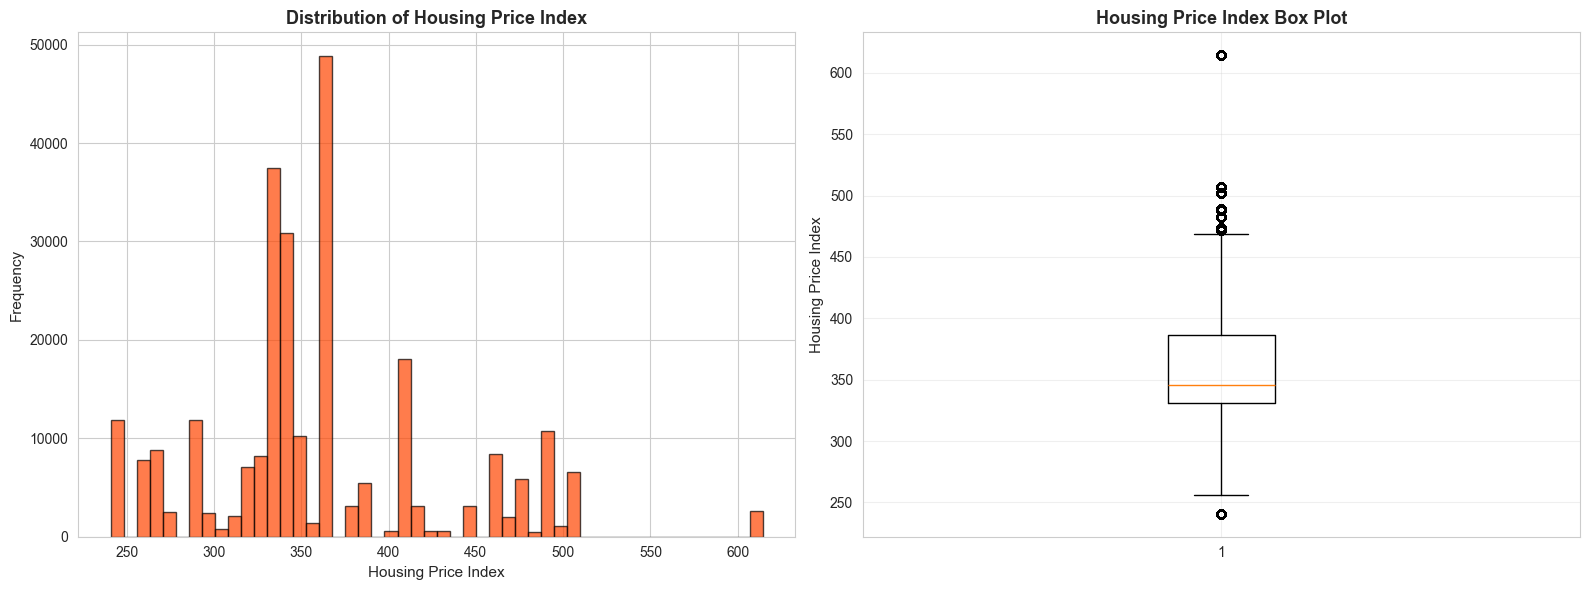

In [21]:
# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1.hist(df['hpi_index'].dropna(), bins=50, color='orangered', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Housing Price Index', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of Housing Price Index', fontsize=13, fontweight='bold')

# Box plot
ax2.boxplot(df['hpi_index'].dropna(), vert=True)
ax2.set_ylabel('Housing Price Index', fontsize=11)
ax2.set_title('Housing Price Index Box Plot', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================================
# 7. CITY-LEVEL AGGREGATION
# ============================================================================
print("\n" + "="*80)
print("7. CITY-LEVEL AGGREGATION")
print("="*80)


7. CITY-LEVEL AGGREGATION


In [23]:
city_stats = df.groupby('city_x').agg({
    'size_numeric': ['mean', 'median', 'std', 'count'],
    'hpi_index': ['mean', 'median', 'std']
}).reset_index()

In [24]:
city_stats.columns = ['city', 'avg_firm_size', 'median_firm_size', 'std_firm_size', 
                      'company_count', 'avg_hpi', 'median_hpi', 'std_hpi']
city_stats = city_stats.dropna()

In [25]:
print(f"\nCity Statistics Summary:")
print(city_stats.describe())


City Statistics Summary:
       avg_firm_size  median_firm_size  std_firm_size  company_count  \
count    7285.000000       7285.000000    7285.000000    7285.000000   
mean      523.974230        257.687131     816.377933      36.280027   
std       761.254236        705.502884    1124.480756     188.412513   
min       125.500000        125.500000       0.000000       2.000000   
25%       157.642857        125.500000      78.915642       3.000000   
50%       238.000000        125.500000     159.099026       6.000000   
75%       612.947917        125.500000    1377.894366      20.000000   
max     10000.000000      10000.000000    6982.325911    9185.000000   

           avg_hpi   median_hpi      std_hpi  
count  7285.000000  7285.000000  7285.000000  
mean    359.135083   359.028590    10.705166  
std      69.705136    72.307586    24.547200  
min     240.770000   240.770000     0.000000  
25%     319.110000   319.110000     0.000000  
50%     343.730000   343.730000     0.00000

In [26]:
print(f"\nTop 10 cities by average firm size:")
print(city_stats.nlargest(10, 'avg_firm_size')[['city', 'avg_firm_size', 'company_count', 'avg_hpi']])


Top 10 cities by average firm size:
                                      city  avg_firm_size  company_count  \
735                                   Base        10000.0              2   
4671                            Greesnboro        10000.0              2   
4672                           Gregg-Adams        10000.0              2   
5896                                Kieler        10000.0              2   
6755                          Lyon Station        10000.0              2   
4870                         Harbor-Hickam         8750.0              2   
118   Ait Iazza Freija Taroudant Taroudant         7500.0              2   
9126                              Pentagon         6783.5              3   
1662                       Calabasas Hills         6708.5              3   
5999                                Kohler         6708.5              3   

      avg_hpi  
735    384.58  
4671   507.29  
4672   352.54  
5896   331.90  
6755   288.45  
4870   471.99  
118    363.15 

In [27]:
print(f"\nTop 10 cities by average HPI:")
print(city_stats.nlargest(10, 'avg_hpi')[['city', 'avg_hpi', 'company_count', 'avg_firm_size']])


Top 10 cities by average HPI:
               city  avg_hpi  company_count  avg_firm_size
102           Aiken   614.29             25     695.440000
662         Bamberg   614.29              3     125.500000
710        Barnwell   614.29              2     350.500000
948   Bennettsville   614.29              3     200.500000
1175     Blythewood   614.29              3    2041.833333
1733     Campobello   614.29              2     125.500000
1920          Cayce   614.29              6     125.500000
2042         Chapin   614.29              3     200.500000
2102         Cheraw   614.29              4     181.750000
2306        Clemson   614.29             44    1139.613636


In [28]:
print(f"\nTop 10 cities by company count:")
print(city_stats.nlargest(10, 'company_count')[['city', 'company_count', 'avg_firm_size', 'avg_hpi']])


Top 10 cities by company count:
                city  company_count  avg_firm_size     avg_hpi
8162        New York           9185     737.519760  337.867032
5299         Houston           4806     642.282772  343.687920
6648     Los Angeles           3798     693.062401  364.120466
2140         Chicago           3764     745.003321  240.816767
10341  San Francisco           3430     662.843732  364.022488
2771          Dallas           2897     747.653780  343.901619
7296           Miami           2757     560.626406  406.917979
524          Atlanta           2680     891.166045  256.091211
564           Austin           2611     571.264075  343.659628
12542     Washington           2446    1100.158217  363.344365


In [29]:
# ============================================================================
# 8. CORRELATION ANALYSIS: FIRM SIZE vs HOUSING PRICES
# ============================================================================
print("\n" + "="*80)
print("8. FIRM SIZE vs HOUSING PRICE CORRELATION")
print("="*80)


8. FIRM SIZE vs HOUSING PRICE CORRELATION


In [30]:
# Calculate correlations
corr_pearson = city_stats['avg_firm_size'].corr(city_stats['avg_hpi'])
corr_spearman = city_stats['avg_firm_size'].corr(city_stats['avg_hpi'], method='spearman')
r, p_value = stats.pearsonr(city_stats['avg_firm_size'], city_stats['avg_hpi'])

In [31]:
print(f"\nPearson Correlation: {corr_pearson:.4f}")
print(f"Spearman Correlation: {corr_spearman:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Number of cities: {len(city_stats)}")


Pearson Correlation: -0.0151
Spearman Correlation: 0.0059
P-value: 0.1980
Number of cities: 7285


In [32]:
if p_value < 0.001:
    significance = "highly significant (p < 0.001)"
elif p_value < 0.01:
    significance = "very significant (p < 0.01)"
elif p_value < 0.05:
    significance = "significant (p < 0.05)"
else:
    significance = "not significant (p >= 0.05)"

In [33]:
print(f"Statistical significance: {significance}")

Statistical significance: not significant (p >= 0.05)


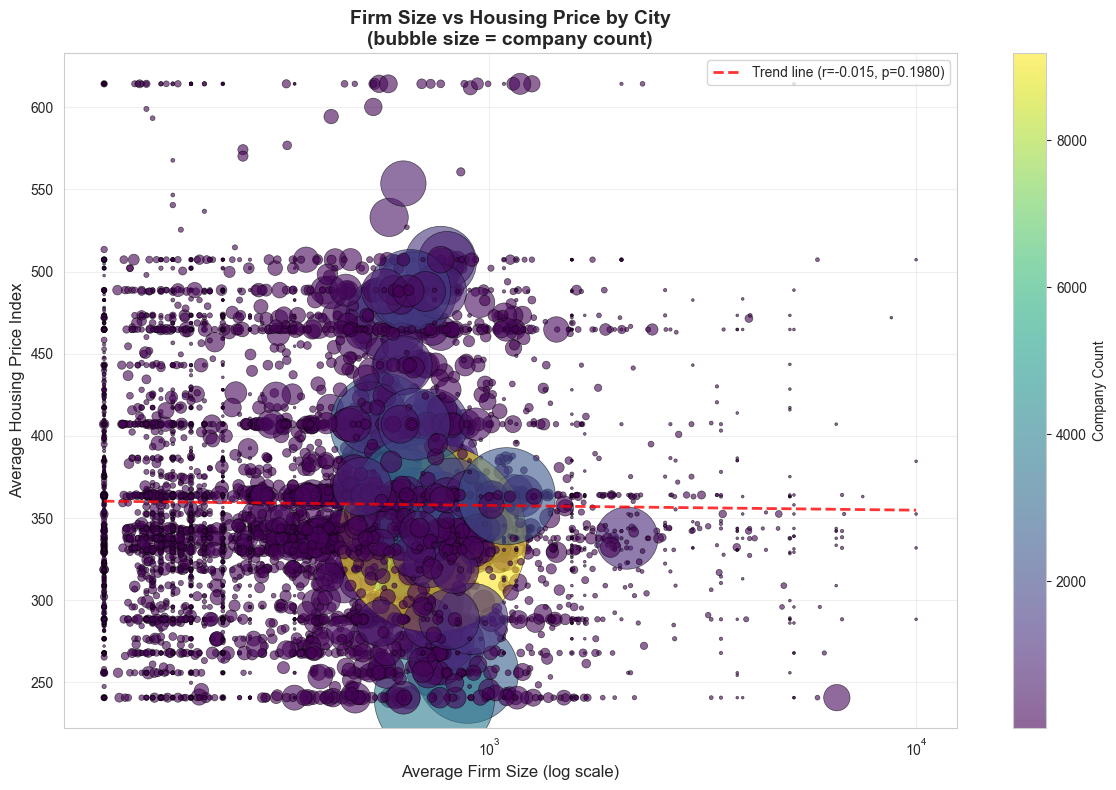

In [34]:
# Visualize
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(city_stats['avg_firm_size'],
                     city_stats['avg_hpi'],
                     s=city_stats['company_count']*2,
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5,
                     c=city_stats['company_count'],
                     cmap='viridis')

# Add trend line
z = np.polyfit(np.log10(city_stats['avg_firm_size']), 
               city_stats['avg_hpi'], 1)
p = np.poly1d(z)
x_trend = np.logspace(np.log10(city_stats['avg_firm_size'].min()),
                      np.log10(city_stats['avg_firm_size'].max()), 100)
ax.plot(x_trend, p(np.log10(x_trend)), 
        "r--", alpha=0.8, linewidth=2, 
        label=f'Trend line (r={corr_pearson:.3f}, p={p_value:.4f})')

ax.set_xscale('log')
ax.set_xlabel('Average Firm Size (log scale)', fontsize=12)
ax.set_ylabel('Average Housing Price Index', fontsize=12)
ax.set_title('Firm Size vs Housing Price by City\n(bubble size = company count)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Company Count', fontsize=10)

plt.tight_layout()
plt.show()

In [35]:
# ============================================================================
# 9. INDUSTRY CONCENTRATION BY CITY
# ============================================================================
print("\n" + "="*80)
print("9. INDUSTRY CONCENTRATION BY CITY")
print("="*80)


9. INDUSTRY CONCENTRATION BY CITY


Total cities before filtering: 13330
Cities with >= 10 companies: 2966

Top 10 most concentrated cities (by HHI):
                 city       hhi
2359            Scott  0.540000
1332        Lake Park  0.472222
321         Broussard  0.429450
2239  Rolling Meadows  0.422037
881        Fort Bragg  0.414062
880      Fort Belvoir  0.386667
505             Clute  0.375000
2704           Vernal  0.368056
1869       Notre Dame  0.366255
1789    New York City  0.356623

Top 10 most diversified cities (by HHI):
                city       hhi
2279     Saint Louis  0.018629
1626     Minneapolis  0.018252
2288  Salt Lake City  0.017706
2106        Portland  0.017650
2057      Pittsburgh  0.017506
1591           Miami  0.017321
1622       Milwaukee  0.016972
398       Casablanca  0.016835
1451     Los Angeles  0.016647
497        Cleveland  0.016094

Median HHI (filtered cities): 0.066


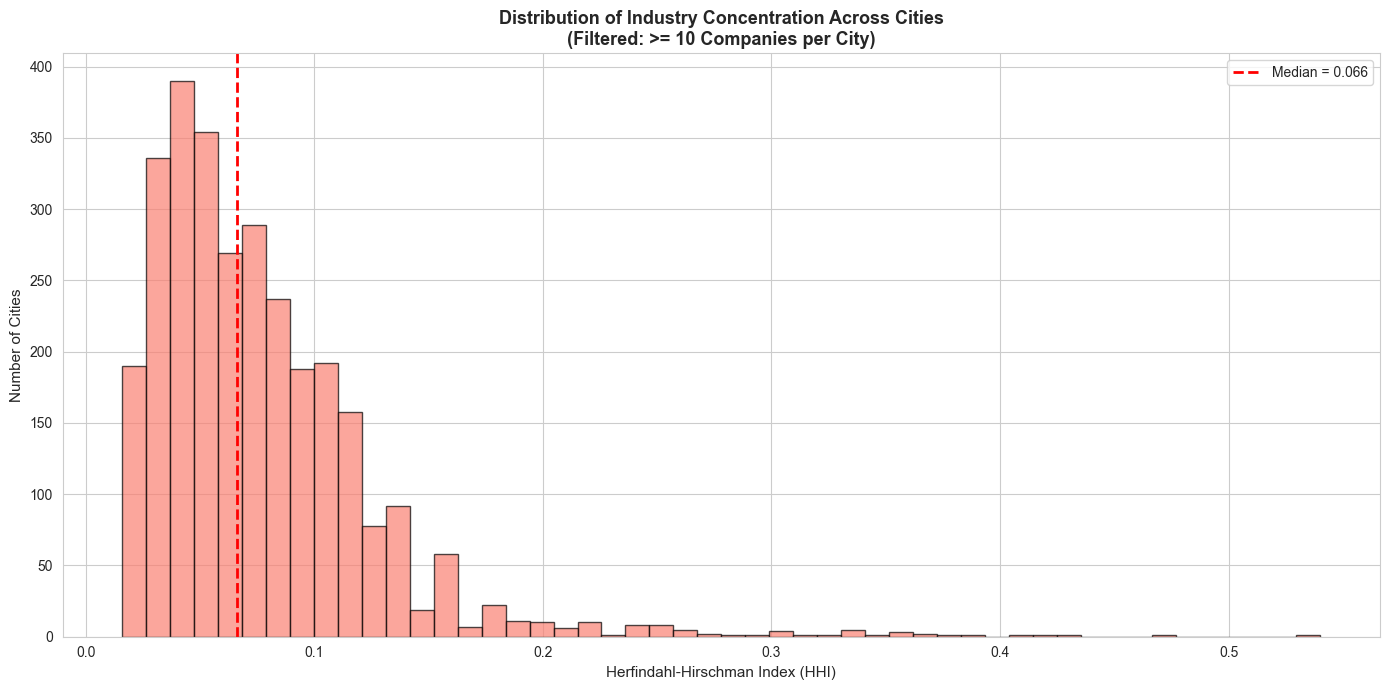

In [36]:
if 'industry' in df.columns:
    
    # -----------------------------
    # Step 1: Compute company counts per city
    # -----------------------------
    city_totals = df.groupby('city_x').size().reset_index(name='total')
    
    # Filter: Keep only cities with at least N companies
    MIN_COMPANIES = 10   # You can change this threshold
    valid_cities = city_totals[city_totals['total'] >= MIN_COMPANIES]['city_x']
    
    df_filtered = df[df['city_x'].isin(valid_cities)].copy()
    
    print(f"Total cities before filtering: {city_totals.shape[0]}")
    print(f"Cities with >= {MIN_COMPANIES} companies: {len(valid_cities)}")
    
    # -----------------------------
    # Step 2: Calculate HHI
    # -----------------------------
    city_industry = (
        df_filtered
        .groupby(['city_x', 'industry'])
        .size()
        .reset_index(name='count')
    )
    
    city_totals_filtered = (
        df_filtered
        .groupby('city_x')
        .size()
        .reset_index(name='total')
    )
    
    city_industry = city_industry.merge(city_totals_filtered, on='city_x')
    
    city_industry['share'] = city_industry['count'] / city_industry['total']
    city_industry['share_squared'] = city_industry['share'] ** 2
    
    hhi = (
        city_industry
        .groupby('city_x')['share_squared']
        .sum()
        .reset_index()
    )
    
    hhi.columns = ['city', 'hhi']
    hhi = hhi.sort_values('hhi', ascending=False)
    
    # -----------------------------
    # Step 3: Print Results
    # -----------------------------
    print(f"\nTop 10 most concentrated cities (by HHI):")
    print(hhi.head(10))
    
    print(f"\nTop 10 most diversified cities (by HHI):")
    print(hhi.tail(10))
    
    print(f"\nMedian HHI (filtered cities): {hhi['hhi'].median():.3f}")
    
    # -----------------------------
    # Step 4: Visualization
    # -----------------------------
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.hist(hhi['hhi'], bins=50, color='salmon',
            edgecolor='black', alpha=0.7)
    
    ax.set_xlabel('Herfindahl-Hirschman Index (HHI)', fontsize=11)
    ax.set_ylabel('Number of Cities', fontsize=11)
    ax.set_title(
        f'Distribution of Industry Concentration Across Cities\n'
        f'(Filtered: >= {MIN_COMPANIES} Companies per City)',
        fontsize=13, fontweight='bold'
    )
    
    median_hhi = hhi['hhi'].median()
    ax.axvline(median_hhi,
               color='red',
               linestyle='--',
               linewidth=2,
               label=f'Median = {median_hhi:.3f}')
    
    ax.legend()
    plt.tight_layout()
    plt.show()


In [40]:
# ============================================================================
# 10. KEY INSIGHTS SUMMARY
# ============================================================================
print("\n" + "="*80)
print("10. KEY INSIGHTS SUMMARY")
print("="*80)


10. KEY INSIGHTS SUMMARY


In [41]:
print(f"""
Dataset Overview:
- Total companies: {len(df):,}
- Total cities: {df['city_x'].nunique()}
- Average companies per city: {len(df) / df['city_x'].nunique():.1f}

Firm Size:
- Mean: {df['size_numeric'].mean():.0f}
- Median: {df['size_numeric'].median():.0f}
- Range: {df['size_numeric'].min():.0f} - {df['size_numeric'].max():.0f}

Housing Prices:
- Mean HPI: {df['hpi_index'].mean():.1f}
- Median HPI: {df['hpi_index'].median():.1f}
- Range: {df['hpi_index'].min():.1f} - {df['hpi_index'].max():.1f}

Firm Size vs Housing Price Relationship:
- Correlation: {corr_pearson:.4f}
- Significance: {significance}
- Interpretation: {"Positive relationship - larger firms associated with higher housing prices" if corr_pearson > 0.3 else "Weak or negative relationship" if corr_pearson > 0 else "Negative relationship"}

Next Steps for Analysis:
1. Time-series analysis of housing price changes
2. Industry cluster identification (tech hubs, manufacturing centers, etc.)
3. Growth trajectory analysis (which cities are rising vs declining)
4. Predictive modeling for future growth cities
5. Comparison with historical case studies (Detroit, Bay Area, Austin, Seattle)
""")


Dataset Overview:
- Total companies: 275,438
- Total cities: 13330
- Average companies per city: 20.7

Firm Size:
- Mean: 648
- Median: 126
- Range: 126 - 10000

Housing Prices:
- Mean HPI: 361.0
- Median HPI: 345.4
- Range: 240.8 - 614.3

Firm Size vs Housing Price Relationship:
- Correlation: -0.0151
- Significance: not significant (p >= 0.05)
- Interpretation: Negative relationship

Next Steps for Analysis:
1. Time-series analysis of housing price changes
2. Industry cluster identification (tech hubs, manufacturing centers, etc.)
3. Growth trajectory analysis (which cities are rising vs declining)
4. Predictive modeling for future growth cities
5. Comparison with historical case studies (Detroit, Bay Area, Austin, Seattle)



In [42]:
print("="*80)
print("EDA COMPLETE")
print("="*80)

EDA COMPLETE
